<a href="https://colab.research.google.com/github/Saifullah785/Predictive_Maintenance_ML_Projects/blob/main/Project_01_Predictive_Maintenance_Using_Machine_Learning/Project_01_Predictive_Maintenance_Using_Machine_Learning/Project_01_Predictive_Maintenance_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Define the column names
column_names = ['Temperature', 'Vibration', 'Pressure', 'Humidity', 'RPM', 'Voltage', 'Current', 'Sound_Level', 'Oil_Quality', 'Load','Machine Type','Failure Type','Component Type']

# Generate random data for each column
num_rows = 100
data = {
    'Temperature': np.random.uniform(20, 100, num_rows),  # Temperature between 20 and 100
    'Vibration': np.random.uniform(0, 1, num_rows),  # Vibration between 0 and 1
    'Pressure': np.random.uniform(1, 10, num_rows),  # Pressure between 1 and 10
    'Humidity': np.random.uniform(30, 80, num_rows),  # Humidity between 30 and 80
    'RPM': np.random.uniform(1000, 5000, num_rows),  # RPM between 1000 and 5000
    'Voltage': np.random.uniform(110, 240, num_rows),  # Voltage between 110 and 240
    'Current': np.random.uniform(1, 10, num_rows),  # Current between 1 and 10
    'Sound_Level': np.random.uniform(60, 100, num_rows),  # Sound level between 60 and 100
    'Oil_Quality': np.random.uniform(0, 1, num_rows),  # Oil quality between 0 and 1
    'Load': np.random.uniform(0, 100, num_rows),  # Load between 0 and 100
    'Machine Type': np.random.choice(['Pump', 'Motor', 'Compressor', 'Turbine'], num_rows),  # Randomly assigns one of the four machine types to each row
    'Failure Type': np.random.choice(['Overheating', 'Vibration, Wear', 'Electrical', 'No Failure'], num_rows),  # Randomly assigns one of the four failure types to each row
    'Component Type': np.random.choice(['Bearing', 'Gear', 'Seal', 'Fan Blade'], num_rows)  # Randomly assigns one of the four component types to each row
}

# Combine columns to the data to create the dataset
pred = pd.DataFrame(data, columns=column_names)



In [3]:
pred.head()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
0,21.219311,0.469934,5.639938,49.329544,3874.471566,172.952533,6.522687,64.340362,0.623063,74.592378,Compressor,Overheating,Fan Blade
1,67.782362,0.103018,8.818509,67.862256,1511.240279,158.157756,1.595766,99.476786,0.991615,11.234515,Motor,Overheating,Seal
2,38.037836,0.740106,8.174649,65.160607,1861.636049,221.554770,1.469999,75.586153,0.824944,2.532693,Turbine,Overheating,Fan Blade
3,85.737778,0.483536,8.293490,74.515590,1291.000846,169.123486,1.562138,86.914251,0.205902,83.700633,Pump,No Failure,Bearing
4,78.124547,0.969728,7.510969,70.853226,1477.631409,117.310825,1.565783,76.412724,0.591969,41.643224,Turbine,No Failure,Seal


In [4]:
pred.tail()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load,Machine Type,Failure Type,Component Type
95,29.763079,0.530406,4.086034,40.115919,3314.597502,225.448800,9.939821,90.600386,0.009994,30.595638,Turbine,"Vibration, Wear",Gear
96,29.208932,0.667464,1.820698,58.489888,3751.841980,119.611845,1.883235,93.488964,0.395202,75.826086,Pump,No Failure,Seal
97,86.267930,0.187689,4.776209,30.606989,3979.185647,126.345083,9.471602,78.342302,0.897449,42.935330,Compressor,Overheating,Seal
98,74.014842,0.255198,8.960723,71.974193,2602.716773,187.740930,7.033992,81.830149,0.381750,85.038471,Compressor,"Vibration, Wear",Fan Blade
99,42.668989,0.208002,6.211466,35.459021,2409.557676,110.788452,7.523202,81.579479,0.258143,69.183382,Motor,No Failure,Fan Blade


# **Exploratory Data Analysis**

In [5]:
pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     100 non-null    float64
 1   Vibration       100 non-null    float64
 2   Pressure        100 non-null    float64
 3   Humidity        100 non-null    float64
 4   RPM             100 non-null    float64
 5   Voltage         100 non-null    float64
 6   Current         100 non-null    float64
 7   Sound_Level     100 non-null    float64
 8   Oil_Quality     100 non-null    float64
 9   Load            100 non-null    float64
 10  Machine Type    100 non-null    object 
 11  Failure Type    100 non-null    object 
 12  Component Type  100 non-null    object 
dtypes: float64(10), object(3)
memory usage: 10.3+ KB


In [6]:
pred.describe()

,Temperature,Vibration,Pressure,Humidity,RPM,Voltage,Current,Sound_Level,Oil_Quality,Load
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,58.124774,0.484318,5.326236,55.372249,2856.052898,179.473235,5.542687,81.934105,0.498463,46.999118
std,24.621812,0.273862,2.661008,14.916940,1193.215700,40.169901,2.598799,11.699675,0.277394,29.097061
min,20.589709,0.019500,1.125192,30.147321,1016.359089,110.581054,1.229337,60.851103,0.007554,0.468449
25%,35.761285,0.229067,2.820349,42.165199,1730.578708,144.848159,3.062453,71.876738,0.311050,20.921694
50%,55.091933,0.476735,5.393291,55.543585,2553.183907,187.731900,6.106937,83.693886,0.490795,42.959199
75%,82.412896,0.698808,7.552034,67.902664,3946.212216,217.939248,7.586245,91.824636,0.700928,73.989624
max,99.785572,0.990071,9.978770,79.950609,4950.584621,239.829140,9.939821,99.883788,0.991615,99.128163


             Temperature  Vibration  Pressure  Humidity       RPM   Voltage  \
Temperature     1.000000  -0.035273 -0.129106 -0.124832  0.074273  0.083068   
Vibration      -0.035273   1.000000 -0.075254  0.031279 -0.009894  0.039368   
Pressure       -0.129106  -0.075254  1.000000  0.050529 -0.088012 -0.067299   
Humidity       -0.124832   0.031279  0.050529  1.000000 -0.122374 -0.101817   
RPM             0.074273  -0.009894 -0.088012 -0.122374  1.000000  0.105734   
Voltage         0.083068   0.039368 -0.067299 -0.101817  0.105734  1.000000   
Current        -0.199798  -0.039238  0.023467 -0.034869 -0.050042  0.180683   
Sound_Level    -0.160213   0.101616  0.147641 -0.056733  0.009326  0.065177   
Oil_Quality    -0.068808   0.038729 -0.018590  0.163621  0.034403  0.005326   
Load           -0.014628  -0.179061  0.132739  0.161783  0.156008 -0.121169   

              Current  Sound_Level  Oil_Quality      Load  
Temperature -0.199798    -0.160213    -0.068808 -0.014628  
Vibration 

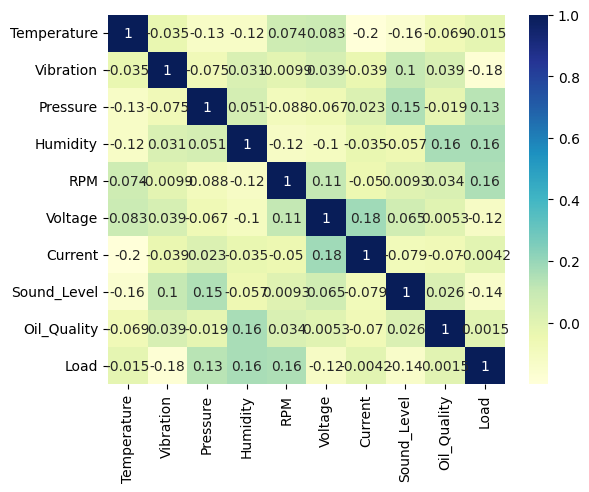

In [8]:
co_mtx = pred.corr(numeric_only=True)

print(co_mtx)

sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

plt.show()